In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

#### TASK-A DATASET Exploration (Task A → Binary detection)

In [2]:
train_df = pd.read_parquet("../data/task_a/train.parquet")
val_df = pd.read_parquet("../data/task_a/val.parquet")

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 500000
Validation size: 100000


In [3]:
print("Columns:")
print(train_df.columns)

print("\nSample rows:")
train_df.head()

Columns:
Index(['code', 'generator', 'label', 'language'], dtype='object')

Sample rows:


,code,generator,label,language
0,"(a, b, c, d) = [int(x) for x in input().split(...",human,0,Python
1,valid version for the language; all others can...,Qwen/Qwen2.5-Coder-1.5B,1,Python
2,python\ndef min_cards_to_flip(s):\n vowels ...,Qwen/Qwen2.5-Coder-7B-Instruct,1,Python
3,T = int(input())\nfor t in range(T):\n\tcolor ...,human,0,Python
4,for i in range(int(input())):\n\tinput()\n\ta ...,human,0,Python


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   code       500000 non-null  object
 1   generator  500000 non-null  object
 2   label      500000 non-null  int64 
 3   language   500000 non-null  object
dtypes: int64(1), object(3)
memory usage: 15.3+ MB


Class Distribution

In [5]:
print("Class Distribution:")
print(train_df['label'].value_counts())

print("\nClass Distribution (Percentage):")
print(train_df['label'].value_counts(normalize=True) * 100)

Class Distribution:
label
1    261525
0    238475
Name: count, dtype: int64

Class Distribution (Percentage):
label
1    52.305
0    47.695
Name: proportion, dtype: float64


Language Distribution

In [6]:
print("Language Distribution:")
print(train_df['language'].value_counts())

Language Distribution:
language
Python    457306
C++        23392
Java       19302
Name: count, dtype: int64


Generator Distribution

In [7]:
print("Generator Distribution:")
print(train_df['generator'].value_counts())

Generator Distribution:
generator
human                                       238475
microsoft/Phi-3-medium-4k-instruct           16545
microsoft/Phi-3.5-mini-instruct               9869
01-ai/Yi-Coder-9B                             9815
bigcode/starcoder                             9780
microsoft/phi-2                               9494
Qwen/Qwen2.5-Coder-1.5B-Instruct              9017
bigcode/starcoder2-15b                        8824
meta-llama/Llama-3.3-70B-Instruct             8760
codellama/CodeLlama-70b-Instruct-hf           8715
microsoft/Phi-3-mini-4k-instruct              8681
bigcode/starcoder2-3b                         8661
01-ai/Yi-Coder-1.5B                           8633
microsoft/Phi-3-small-8k-instruct             8606
meta-llama/Llama-3.1-8B-Instruct              8374
Qwen/Qwen2.5-Coder-32B-Instruct               8189
01-ai/Yi-Coder-9B-Chat                        8153
codellama/CodeLlama-34b-Instruct-hf           8006
google/codegemma-2b                           75

The Task A dataset consists of 500,000 training samples and 100,000 validation samples. The dataset is nearly balanced, with 52.3% machine-generated and 47.7% human-written code.

The dataset spans three programming languages: Python (91%), C++, and Java. The dominance of Python enables controlled out-of-distribution experiments by training on Python and evaluating on C++/Java.

Machine-generated samples are produced by more than 30 large language models, including Llama, CodeLlama, Qwen, StarCoder, Phi, and DeepSeek families, enabling analysis across multi-generator settings.

In [8]:
train_df['length'] = train_df['code'].apply(lambda x: len(str(x).split()))

print("Average Length Per Class:")
print(train_df.groupby('label')['length'].mean())

Average Length Per Class:
label
0     94.491452
1    146.501547
Name: length, dtype: float64


In [9]:
print("\nAverage Length Per Language:")
print(train_df.groupby('language')['length'].mean())


Average Length Per Language:
language
C++       209.374188
Java      246.659362
Python    111.935916
Name: length, dtype: float64


Preliminary analysis reveals that machine-generated code snippets are significantly longer on average (146 tokens) compared to human-written code (94 tokens). Additionally, substantial variation exists across programming languages, with Java snippets being the longest. These observations suggest that naive models may exploit length-based biases, motivating more structural analysis beyond surface-level statistics.

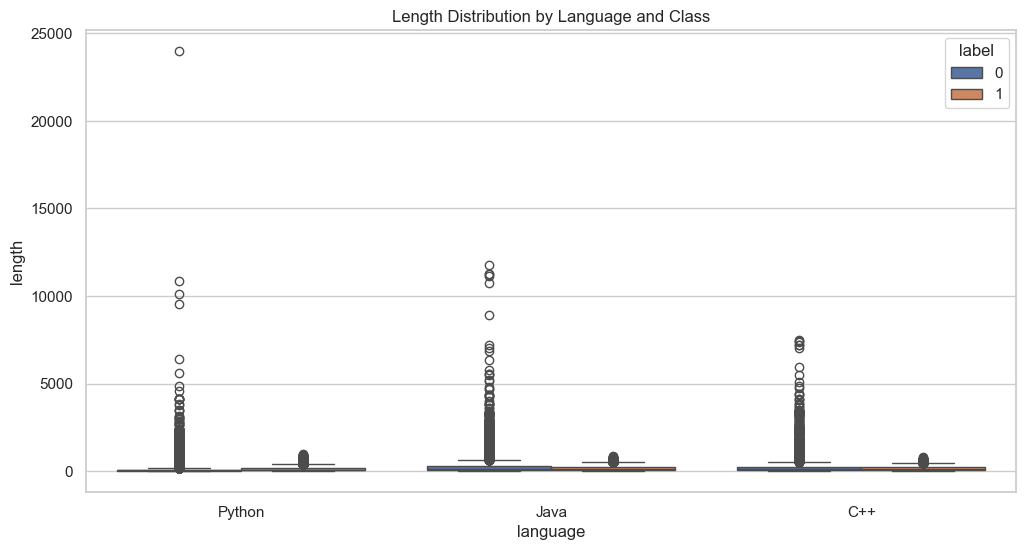

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=train_df, x='language', y='length', hue='label')
plt.title("Length Distribution by Language and Class")
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = train_df[['length']]
y = train_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy using ONLY length:", accuracy_score(y_test, preds))

Accuracy using ONLY length: 0.62376


Insights:
Machine-generated code tends to be longer across all languages.

Length alone provides moderate predictive power (~62%), but substantial class overlap exists.

Language affects length strongly (Java > C++ > Python).

A simple logistic regression model trained solely on snippet length achieves 62.3% accuracy, indicating that length contributes predictive signal but is insufficient for robust detection. This motivates the need for deeper structural and semantic analysis beyond surface-level statistics.

-----> Is length bias consistent per language?

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

for lang in train_df['language'].unique():
    subset = train_df[train_df['language'] == lang]
    
    X = subset[['length']]
    y = subset['label']
    
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    print(f"{lang} - Length-only Accuracy: {acc:.4f}")

Python - Length-only Accuracy: 0.6349
Java - Length-only Accuracy: 0.5372
C++ - Length-only Accuracy: 0.5302


While length alone achieves 63.4% accuracy on Python snippets, its predictive power drops to approximately 53% on Java and C++, indicating that length-based bias is language-dependent and insufficient for robust cross-language detection.

#### Generator vs Language Cross Analysis

In [13]:
pd.crosstab(train_df['generator'], train_df['language']).head(20)

language,C++,Java,Python
generator,,,
01-ai/Yi-Coder-1.5B,352,318,7963
01-ai/Yi-Coder-1.5B-Chat,246,245,6338
01-ai/Yi-Coder-9B,400,366,9049
01-ai/Yi-Coder-9B-Chat,393,304,7456
Qwen/Qwen2.5-Coder-1.5B,258,227,6132
Qwen/Qwen2.5-Coder-1.5B-Instruct,440,356,8221
Qwen/Qwen2.5-Coder-32B-Instruct,420,366,7403
Qwen/Qwen2.5-Coder-7B,333,238,6435
Qwen/Qwen2.5-Coder-7B-Instruct,350,271,5901


#### Class Distribution Per Language

In [14]:
pd.crosstab(train_df['language'], train_df['label'], normalize='index') * 100

label,0,1
language,,
C++,47.653044,52.346956
Java,47.792975,52.207025
Python,47.693011,52.306989


#### Generator Distribution Per Class 

In [15]:
pd.crosstab(train_df['generator'], train_df['label']).head(10)

label,0,1
generator,,
01-ai/Yi-Coder-1.5B,0,8633
01-ai/Yi-Coder-1.5B-Chat,0,6829
01-ai/Yi-Coder-9B,0,9815
01-ai/Yi-Coder-9B-Chat,0,8153
Qwen/Qwen2.5-Coder-1.5B,0,6617
Qwen/Qwen2.5-Coder-1.5B-Instruct,0,9017
Qwen/Qwen2.5-Coder-32B-Instruct,0,8189
Qwen/Qwen2.5-Coder-7B,0,7006
Qwen/Qwen2.5-Coder-7B-Instruct,0,6522


#### Extreme Outliers Analysis

In [16]:
train_df['length'].describe()

count    500000.000000
mean        121.695332
std         161.588235
min           0.000000
25%          43.000000
50%          74.000000
75%         144.000000
max       23974.000000
Name: length, dtype: float64

In [17]:
train_df[train_df['length'] > 2000].head()

,code,generator,label,language,length
1677,typedef vector<TreeNode*> vt;\ntypedef TreeNod...,human,0,C++,2374
1790,"dat = [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",human,0,Python,4106
3255,// Author: Tyler Wang\n\n#include <algorithm>\...,human,0,C++,2347
4733,import java.io.*;\n\nimport java.util.Arrays;\...,human,0,Java,2728
4997,"#line 1 ""/home/maspy/compro/library/my_templat...",human,0,C++,3497


#### Duplicate Check

In [18]:
train_df['code'].duplicated().sum()

np.int64(0)

#### Validation Set Consistency

In [19]:
val_df['label'].value_counts(normalize=True)
val_df['language'].value_counts(normalize=True)

language
Python    0.91461
C++       0.04679
Java      0.03860
Name: proportion, dtype: float64

In [20]:
train_df.groupby(['language','label'])['length'].mean()

language  label
C++       0        247.989773
          1        174.221233
Java      0        317.652033
          1        181.669048
Python    0         77.207407
          1        143.601038
Name: length, dtype: float64

Length-based differences between human and machine code are strongly language-dependent, with opposite trends observed between Python and statically typed languages like Java and C++, indicating that superficial statistics alone are insufficient for robust cross-language detection.

# Exploring Val dataset 

In [26]:
print("Validation Class Distribution:")
print(val_df['label'].value_counts(normalize=True))

print("\nValidation Language Distribution:")
print(val_df['language'].value_counts(normalize=True))

Validation Class Distribution:
label
1    0.52305
0    0.47695
Name: proportion, dtype: float64

Validation Language Distribution:
language
Python    0.91461
C++       0.04679
Java      0.03860
Name: proportion, dtype: float64


#### Length Comparison (Train vs Val)

In [27]:
val_df['length'] = val_df['code'].apply(lambda x: len(str(x).split()))

print("Train Length Mean:", train_df['length'].mean())
print("Validation Length Mean:", val_df['length'].mean())

print("\nValidation Avg Length Per Class:")
print(val_df.groupby('label')['length'].mean())

Train Length Mean: 121.695332
Validation Length Mean: 121.33327

Validation Avg Length Per Class:
label
0     93.921313
1    146.329223
Name: length, dtype: float64


#### Generator Distribution in Validation

In [28]:
print("Validation Generator Distribution:")
print(val_df['generator'].value_counts().head(15))

Validation Generator Distribution:
generator
human                                  47695
microsoft/Phi-3-medium-4k-instruct      3165
microsoft/Phi-3.5-mini-instruct         2047
microsoft/phi-2                         1966
01-ai/Yi-Coder-9B                       1950
Qwen/Qwen2.5-Coder-1.5B-Instruct        1903
bigcode/starcoder2-15b                  1872
bigcode/starcoder                       1857
microsoft/Phi-3-small-8k-instruct       1814
bigcode/starcoder2-3b                   1760
meta-llama/Llama-3.3-70B-Instruct       1756
codellama/CodeLlama-70b-Instruct-hf     1742
01-ai/Yi-Coder-1.5B                     1732
microsoft/Phi-3-mini-4k-instruct        1667
01-ai/Yi-Coder-9B-Chat                  1665
Name: count, dtype: int64


### Duplicate Check Between Train & Val


In [29]:
train_codes = set(train_df['code'])
val_overlap = val_df['code'].isin(train_codes).sum()

print("Number of validation samples appearing in training:", val_overlap)

Number of validation samples appearing in training: 0


# Exploring Test dataset

### Load Test Dataset

In [21]:
test_df = pd.read_parquet("../data/task_a/test_sample.parquet")

print("Test size:", len(test_df))
print("\nColumns:")
print(test_df.columns)

test_df.head()

Test size: 1000

Columns:
Index(['code', 'generator', 'label', 'language'], dtype='object')


,code,generator,label,language
0,public Vector To(Vector o)\n {\n ...,Human,0,C#
1,func (v *DefaultMessageSyntaxValidator) Valida...,Human,0,Go
2,"""""""Module managing testsuite capabilities\n\nC...",Human,0,Python
3,void Anvil::Image::on_memory_backing_opaque_up...,Human,0,C++
4,bool NOMAD::Priority_Eval_Point::dominates\n( ...,Human,0,C++


In [22]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   code       1000 non-null   object
 1   generator  1000 non-null   object
 2   label      1000 non-null   int64 
 3   language   1000 non-null   object
dtypes: int64(1), object(3)
memory usage: 31.4+ KB


#### Check Distributions

In [23]:
print("\nClass Distribution:")
print(test_df['label'].value_counts(normalize=True))

print("\nLanguage Distribution:")
print(test_df['language'].value_counts(normalize=True))

print("\nGenerator Distribution:")
print(test_df['generator'].value_counts().head(15))


Class Distribution:
label
0    0.777
1    0.223
Name: proportion, dtype: float64

Language Distribution:
language
Python        0.303
Java          0.256
C#            0.122
JavaScript    0.085
C++           0.075
Go            0.060
C             0.051
PHP           0.048
Name: proportion, dtype: float64

Generator Distribution:
generator
Human                                        713
human                                         64
GPT-4o                                        21
deepseek-ai/DeepSeek-V3-0324                  10
01-ai/Yi-Coder-9B-Chat                         8
meta-llama/Llama-4-Scout-17B-16E-Instruct      7
Qwen/Qwen2.5-Coder-1.5B-Instruct               7
mistralai/Mistral-Small-24B-Instruct-2501      7
meta-llama/Llama-3.1-8B-Instruct               7
gemini-2.0-flash-lite                          7
Qwen/Qwen2.5-Coder-7B-Instruct                 6
microsoft/Phi-3-medium-4k-instruct             6
google/gemma-3-27b-it                          6
microsoft/phi-4     

#### Length Analysis

In [24]:
test_df['length'] = test_df['code'].apply(lambda x: len(str(x).split()))

print("\nLength Statistics:")
print(test_df['length'].describe())

print("\nAverage Length Per Language:")
print(test_df.groupby('language')['length'].mean())


Length Statistics:
count    1000.00000
mean      128.30200
std       147.44209
min         6.00000
25%        41.00000
50%        77.00000
75%       150.00000
max      1313.00000
Name: length, dtype: float64

Average Length Per Language:
language
C             162.843137
C#            108.819672
C++           157.133333
Go            104.733333
Java          144.562500
JavaScript    106.658824
PHP           158.750000
Python        115.372937
Name: length, dtype: float64


#### Compare Train vs Test Distributions

In [25]:
print("Train Language Distribution:")
print(train_df['language'].value_counts(normalize=True))

print("\nTest Language Distribution:")
print(test_df['language'].value_counts(normalize=True))

Train Language Distribution:
language
Python    0.914612
C++       0.046784
Java      0.038604
Name: proportion, dtype: float64

Test Language Distribution:
language
Python        0.303
Java          0.256
C#            0.122
JavaScript    0.085
C++           0.075
Go            0.060
C             0.051
PHP           0.048
Name: proportion, dtype: float64
